# Rep. 3. Checkpoint 1. Valuación de opciones europeas

sara hernandez y edgardo Gonzalez

## Parte 1 — Volatilidad

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
ticker = 'SPY'

data = yf.download(ticker, start='2022-01-01', end='2026-03-10')['Close']['SPY']

data.tail()

[*********************100%***********************]  1 of 1 completed


Date
2026-03-03    680.330017
2026-03-04    685.130005
2026-03-05    681.309998
2026-03-06    672.380005
2026-03-09    678.270020
Name: SPY, dtype: float64

In [3]:
daily_returns = data.pct_change()
daily_returns = daily_returns.dropna()

sigma = daily_returns.std() * np.sqrt(252)

sigma

np.float64(0.17792090626618312)

In [4]:
S0 = data.iloc[-1]   # precio actual del activo
r = 0.08             # tasa libre de riesgo
T = 100 / 365        # tiempo al vencimiento (100 días)

K = 680              # precio strike

num_simulations = 10000

In [5]:
sigmas = [0.01, 0.10, 0.20, 0.40]

In [6]:
results = {}

for sigma in sigmas:
    
    Z = np.random.normal(0, 1, num_simulations)
    
    St = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    results[sigma] = St

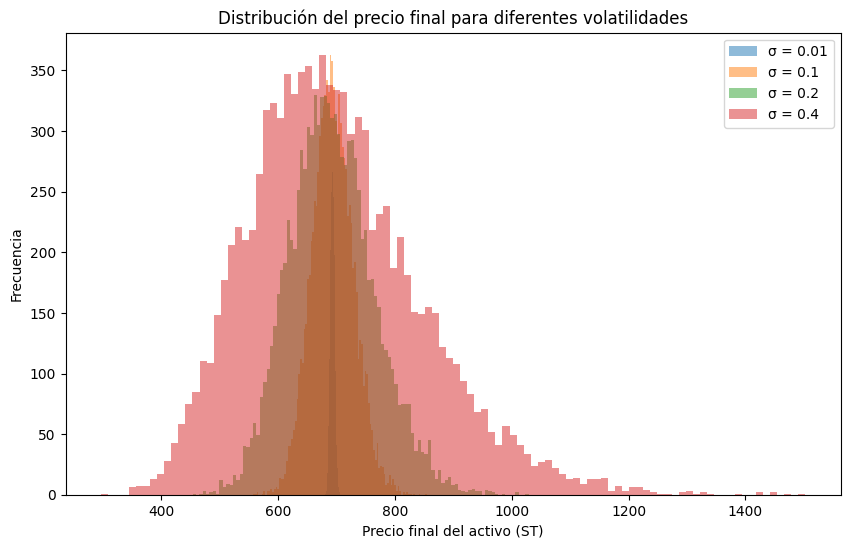

In [7]:
plt.figure(figsize=(10,6))

for sigma in sigmas:
    plt.hist(results[sigma], bins=100, alpha=0.5, label=f'σ = {sigma}')

plt.xlabel("Precio final del activo (ST)")
plt.ylabel("Frecuencia")
plt.title("Distribución del precio final para diferentes volatilidades")
plt.legend()

plt.show()

In [8]:
call_values = []
put_values = []

for sigma in sigmas:
    
    St = results[sigma]
    
    call = np.maximum(St - K, 0)
    put = np.maximum(K - St, 0)
    
    call_value = np.exp(-r * T) * np.mean(call)
    put_value = np.exp(-r * T) * np.mean(put)
    
    call_values.append(call_value)
    put_values.append(put_value)

In [9]:
call_table = pd.DataFrame({
    'Volatilidad (σ)': sigmas,
    'Valor Call': call_values
})

call_table

,Volatilidad (σ),Valor Call
0,0.01,12.986716
1,0.10,21.309452
2,0.20,34.375597
3,0.40,64.924206


In [10]:
put_table = pd.DataFrame({
    'Volatilidad (σ)': sigmas,
    'Valor Put': put_values
})

put_table

,Volatilidad (σ),Valor Put
0,0.01,0.000000
1,0.10,8.028654
2,0.20,22.335895
3,0.40,47.917989


## Actividad 2 — Tiempo al vencimiento


In [11]:
T_values = [30/365, 100/365, 1]

labels_T = ['30 días', '100 días', '1 año']

In [12]:
results_T = {}

for T in T_values:
    
    Z = np.random.normal(0, 1, num_simulations)
    
    St = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    results_T[T] = St

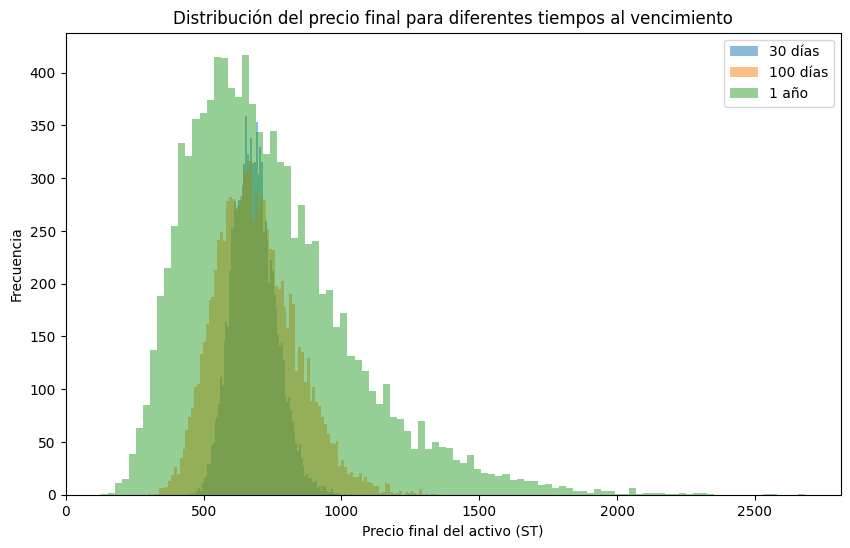

In [13]:
plt.figure(figsize=(10,6))

for T, label in zip(T_values, labels_T):
    plt.hist(results_T[T], bins=100, alpha=0.5, label=label)

plt.xlabel("Precio final del activo (ST)")
plt.ylabel("Frecuencia")
plt.title("Distribución del precio final para diferentes tiempos al vencimiento")
plt.legend()

plt.show()


In [14]:
call_values_T = []
put_values_T = []

for T in T_values:
    
    St = results_T[T]
    
    call = np.maximum(St - K, 0)
    put = np.maximum(K - St, 0)
    
    call_value = np.exp(-r * T) * np.mean(call)
    put_value = np.exp(-r * T) * np.mean(put)
    
    call_values_T.append(call_value)
    put_values_T.append(put_value)
    

In [15]:
call_table_T = pd.DataFrame({
    'Tiempo al vencimiento': labels_T,
    'Valor Call': call_values_T
})

call_table_T


,Tiempo al vencimiento,Valor Call
0,30 días,32.652538
1,100 días,62.093727
2,1 año,131.205551


In [16]:
put_table_T = pd.DataFrame({
    'Tiempo al vencimiento': labels_T,
    'Valor Put': put_values_T
})

put_table_T


,Tiempo al vencimiento,Valor Put
0,30 días,29.593871
1,100 días,50.985838
2,1 año,79.675305


## Actividad 3 — Precio de ejercicio

In [17]:
# Escenarios de precio de ejercicio
K_values = [S0*0.70, S0*0.90, S0, S0*1.10, S0*1.30]

labels_K = ['0.70*S0', '0.90*S0', 'S0', '1.10*S0', '1.30*S0']

call_values_K = []
put_values_K = []

for K in K_values:
    
    Z = np.random.normal(0,1,num_simulations)
    
    St = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    call = np.maximum(St - K, 0)
    put = np.maximum(K - St, 0)
    
    call_value = np.exp(-r*T) * np.mean(call)
    put_value = np.exp(-r*T) * np.mean(put)
    
    call_values_K.append(call_value)
    put_values_K.append(put_value)

# Tabla Call
call_table_K = pd.DataFrame({
    'Strike (K)': labels_K,
    'Valor Call': call_values_K
})

# Tabla Put
put_table_K = pd.DataFrame({
    'Strike (K)': labels_K,
    'Valor Put': put_values_K
})

print("Tabla Call")
print(call_table_K)

print("\nTabla Put")
print(put_table_K)

Tabla Call
  Strike (K)  Valor Call
0    0.70*S0  255.804860
1    0.90*S0  165.655483
2         S0  134.954057
3    1.10*S0  105.215849
4    1.30*S0   61.666168

Tabla Put
  Strike (K)   Valor Put
0    0.70*S0   14.888926
1    0.90*S0   50.908242
2         S0   79.040490
3    1.10*S0  112.731074
4    1.30*S0  195.405269


## Actividad 4 — Tasa libre de riesgo

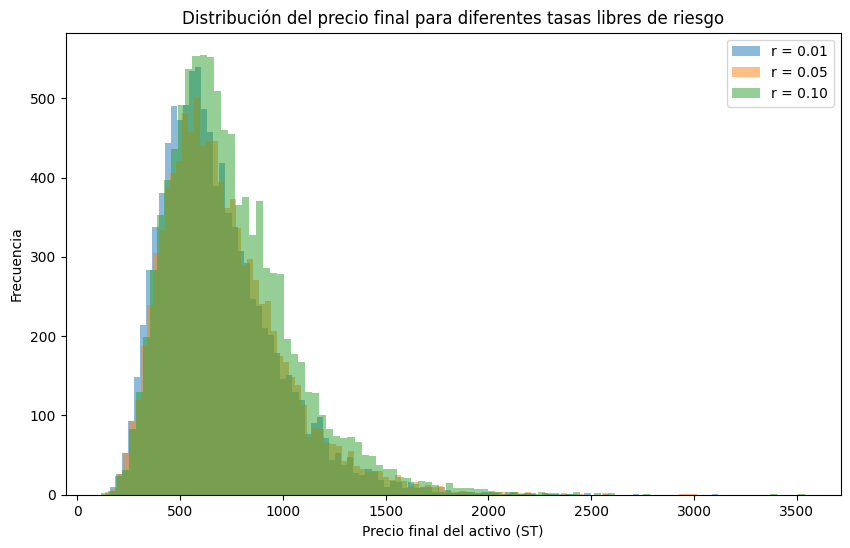

In [18]:
# Escenarios de tasa libre de riesgo
r_values = [0.01, 0.05, 0.10]

labels_r = ['r = 0.01', 'r = 0.05', 'r = 0.10']

results_r = {}

for r in r_values:
    
    Z = np.random.normal(0,1,num_simulations)
    
    St = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    
    results_r[r] = St

# Gráfica de las distribuciones
plt.figure(figsize=(10,6))

for r, label in zip(r_values, labels_r):
    plt.hist(results_r[r], bins=100, alpha=0.5, label=label)

plt.xlabel("Precio final del activo (ST)")
plt.ylabel("Frecuencia")
plt.title("Distribución del precio final para diferentes tasas libres de riesgo")
plt.legend()

plt.show()